In [132]:
import numpy as np

np.random.seed(42)                               #declaring seeds so that every run can produce same input
X = np.random.random(1000)                       # Input
true_m,true_b = 2,5                              # declaring true m(weight) and b(bias)
noise = np.random.randn(1000) * 5                # Gaussain noise
y = true_m* X + true_b + noise                   # Actual Output
m = np.random.random(1)                          # Weight
b = np.random.randint(0,10)                      # Bias

train_data = int(0.8 * X.size)
X_train,X_test = X[:train_data],X[train_data:]  # splitting input into train and test data
y_train,y_test = y[:train_data], y[train_data:] # splitting output in train and test data

In [133]:
#mini batch gradient descent
def gd(X,y,m,b,learning_rate = 0.005,n_epochs = 50):
    n = X.size
    batch_size = 32
    losses = []
    
    for _ in range(n_epochs):    
        indices = np.arange(n)
        np.random.shuffle(indices) 
        X,y= X[indices],y[indices] # shuffling the input and output
        epoch_loss = 0
        for i in range (0,n,batch_size):
            x_batch = X[i:batch_size+i] # slicing input for batch
            y_batch = y[i:batch_size+i] # slicing output for batch
            y_pred = m*x_batch + b      # output prediction based on weight and bias
            epoch_loss += mse(y_batch,y_pred) 
            m_gradient = (2/batch_size) * (np.sum((y_pred - y_batch) * x_batch)) # calculating gradient for weight
            b_gradient = (2/batch_size) * (np.sum(y_pred - y_batch))             # calculating gradient for bias
            m = m - learning_rate * m_gradient
            b = b - learning_rate * b_gradient
        losses.append(epoch_loss)
    return m,b,losses

In [134]:
def mse(actual_val,predicted_val):
    num_item = actual_val.size
    sub = actual_val-predicted_val
    squared = sub**2
    total =  np.sum(squared,dtype=np.float32)
    return total/num_item
    

In [135]:
def r2_score(y_true,y_predict):
    y_true_mean = np.mean(y_true)
    ss_res = np.sum((y_true - y_predict)**2)     # calculating residual sum of squared
    ss_total = np.sum((y_true - y_true_mean)**2) #calculating total sum of squared
    score = 1-(ss_res / ss_total)                # calculating r2 Score
    return score

In [136]:
import matplotlib.pyplot as plt

def graph(x ,y ,style ,xlabel="x" ,ylabel="y" ,title="Graph"):
    plt.figure(figsize=(6,4))
    if style =="scatter":
        plt.scatter(x,y)
    elif style == "plot":
        plt.plot(x,y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
        

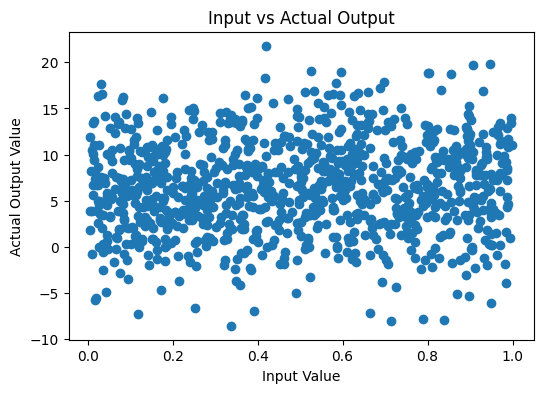

In [137]:
graph(X,y,"scatter","Input Value","Actual Output Value" , "Input vs Actual Output")

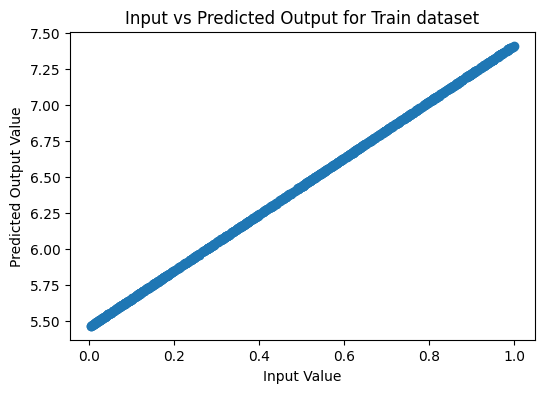

In [138]:
m,b,loss = gd(X_train,y_train,m,b)
y_pred  = m * X_train + b
graph(X_train,y_pred,"scatter","Input Value","Predicted Output Value","Input vs Predicted Output for Train dataset")

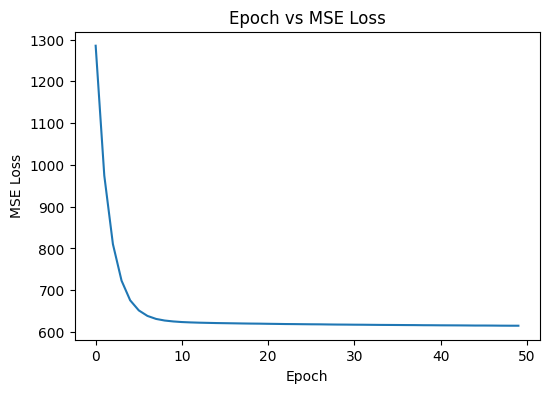

In [139]:
epoch = np.arange(len(loss))
graph(epoch,loss,"plot","Epoch","MSE Loss","Epoch vs MSE Loss")

In [140]:
print(f"For Training Dataset:")
print(f"True weight: {true_m} | Predicted weight: {m[0]}")
print(f"True bias: {true_b}   | Predicted bias: {b}")
print(f"Train MSE: {mse(y_train,y_pred)}")
print(f"Train R2: {r2_score(y_train,y_pred)}")

For Training Dataset:
True weight: 2 | Predicted weight: 1.9541681277582315
True bias: 5   | Predicted bias: 5.454669387160325
Train MSE: 24.581186294555664
Train R2: -0.002025312489672082


In [141]:
y_pred = m * X_test + b
print(f"For Test Dataset:")
print(f"Test MSE: {mse(y_test,y_pred)}")
print(f"Test R2: {r2_score(y_test,y_pred)}")

For Test Dataset:
Test MSE: 23.791610717773438
Test R2: 0.024216978248897125


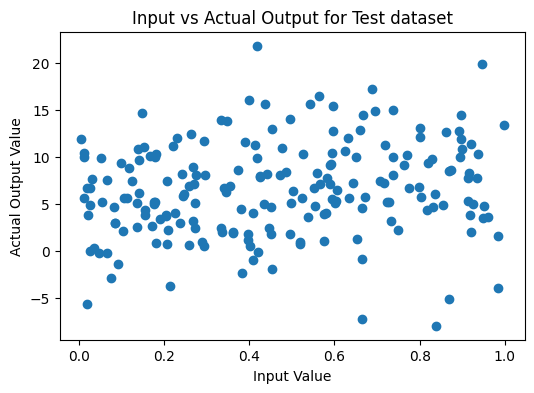

In [142]:
graph(X_test,y_test,"scatter","Input Value", "Actual Output Value","Input vs Actual Output for Test dataset")

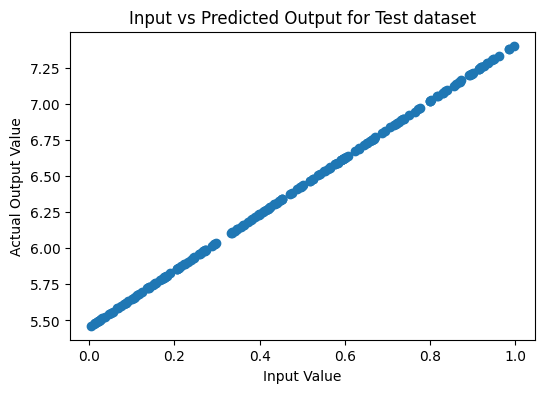

In [143]:
graph(X_test,y_pred,"scatter","Input Value", "Actual Output Value","Input vs Predicted Output for Test dataset")